# RAMIP multi-model pixel KS path-independence (monthly, all matched runs)

Same pairwise test as `ks_path_independence_ramip.ipynb` (GISS daily), extended to the 8 non-GISS RAMIP models transferred from deela ( monthly `Amon` tas only — no daily exists for these).

- Pairwise: `ssp370` (CESM2: `ssp370-LE`, its RAMIP reference) vs `ssp370-126aer`, **matched initial-condition members** both sides.
- **Year-matched window 2041–2050** (largest common full-year decade; CNRM ends 2051-02). NOT GWL-matched: GWL calc blocked on historical runs — see pangeo availability table below. Year-matched difference = aerosol pattern + the GMST offset from faster warming under aerosol cleanup; GWL matching (later) will remove the GMST part.
- KS on raw monthly tas in window, n=120 per side (vs 7300 daily) — much lower power; p-values not comparable in magnitude to the daily GISS/BCD-ME maps.
- Aggregation across runs: authors' `q01 = quantile(0.01, dim='run')`, plotted linear 0–1 (diag_qdm convention). `ks_fast` D-computation as in `ks_path_independence_maps.ipynb`; p via `kstwo.sf(D, round(en))` = scipy `ks_2samp(method='asymp')` exactly (Kolmogorov limit is ~6% off at n=120; fine at daily n=7300).

**Pangeo historical tas Amon availability (for future GWL calc)**, checked 2026-07-08 vs `cmip6-zarr-consolidated-stores.csv`:

| model | on pangeo | missing (→ ESGF) |
|---|---|---|
| CanESM5-1 | 0/10 | all (source_id absent; only CanESM5/CanESM5-CanOE) |
| CESM2 | 10/10 | — (but RAMIP ref is ssp370-LE; name-matched historical may not be the LE branch parent) |
| CNRM-ESM2-1 | 9/10 | r6i1p1f2 |
| EC-Earth3-AerChem | 2/14 | r5–r10 matched runs all missing |
| GISS-E2-1-G | 9/10 | r7i1p3f1 |
| MIROC6 | 10/10 | — |
| MRI-ESM2-0 | 0/10 | r101–r110 all |
| NorESM2-LM | 3/10 | r4–r10 (exactly the RAMIP ssp370 members) |
| UKESM1-0-LL | 10/10 | — |

In [1]:
import os, re, glob
import numpy as np
import xarray as xr
from scipy import stats as sstats
from scipy import special as sspecial
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import regionmask

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
from funcs_support import get_params
dir_list = get_params()

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RAW    = dir_list['raw'] + 'ramip/'
OTHER  = 'ssp370-126aer'
ANCHOR = {m: 'ssp370' for m in
          ['CanESM5-1', 'CNRM-ESM2-1', 'EC-Earth3-AerChem', 'MIROC6',
           'MRI-ESM2-0', 'NorESM2-LM', 'UKESM1-0-LL']}
ANCHOR['CESM2'] = 'ssp370-LE'   # RAMIP's CESM2 reference scenario
MODELS = sorted(ANCHOR)
YEARS  = (2041, 2050)           # largest common full-year decade (CNRM ends 2051-02)
CACHE_DIR = dir_list['aux'] + 'diagnostics/ks_ramip_multi/'
os.makedirs(CACHE_DIR, exist_ok=True)

In [3]:
# D computation as in ks_path_independence_maps.ipynb; p via kstwo.sf(D, round(en))
# = scipy ks_2samp method='asymp' EXACTLY (kolmogorov limit is 6% off at n=120).
# D is discrete (multiples of ~1/n) -> unique+lookup keeps kstwo.sf calls tiny.
def ks_fast(a1, a2):
    P, n1 = a1.shape; n2 = a2.shape[1]
    z = np.concatenate([a1, a2], axis=1)
    order = np.argsort(z, axis=1, kind='stable')
    zs = np.take_along_axis(z, order, axis=1)
    ind = np.where(order < n1, 1.0 / n1, -1.0 / n2)
    cd = np.cumsum(ind, axis=1)
    valid = np.ones_like(cd, dtype=bool)
    valid[:, :-1] = zs[:, 1:] != zs[:, :-1]
    D = np.abs(np.where(valid, cd, 0.0)).max(axis=1)
    en = int(np.round(n1 * n2 / (n1 + n2)))
    uD, inv = np.unique(D, return_inverse=True)
    return np.clip(sstats.kstwo.sf(uD, en), 0, 1)[inv]

def member_files(mod, exp):
    fns = glob.glob(f'{RAW}{mod}/tas_Amon_{mod}_{exp}_r*.zarr')
    return {re.search(r'_(r\d+i\d+p\d+f\d+)_', f).group(1): f for f in fns}

def matched_runs(mod):
    a, b = member_files(mod, ANCHOR[mod]), member_files(mod, OTHER)
    return sorted(set(a) & set(b), key=lambda m: [int(x) for x in re.findall(r'\d+', m)]), a, b

def window_vals(fn):
    ds = xr.open_zarr(fn, consolidated=False)
    da = ds['tas'].sel(time=(ds.time.dt.year >= YEARS[0]) & (ds.time.dt.year <= YEARS[1]))
    v = da.load().transpose('lat', 'lon', 'time')
    return v.values.reshape(-1, v.sizes['time']), v.lat, v.lon, v.sizes['time']

In [4]:
# quick check: ks_fast vs scipy at 3 random pixels of first model/run
runs, afns, bfns = matched_runs(MODELS[0])
va, lat, lon, n1 = window_vals(afns[runs[0]])
vb, *_ , n2      = window_vals(bfns[runs[0]])
rng = np.random.default_rng(0)
for px in rng.choice(va.shape[0], 3, replace=False):
    p_ref = sstats.kstest(va[px], vb[px], method='asymp').pvalue
    p_new = ks_fast(va[px:px+1], vb[px:px+1])[0]
    assert np.isclose(p_new, p_ref, rtol=1e-3), (px, p_new, p_ref)
print(f'ks_fast validated vs scipy (monthly, n={n1} vs {n2})')

ks_fast validated vs scipy (monthly, n=120 vs 120)


In [5]:
results = {}
for mod in MODELS:
    cache_fn = f'{CACHE_DIR}{mod}.nc'
    if os.path.exists(cache_fn):
        results[mod] = xr.open_dataarray(cache_fn).load()
        print(f'{mod}: loaded cache ({results[mod].sizes["run"]} runs)')
        continue
    runs, afns, bfns = matched_runs(mod)
    pvs = []
    for r in runs:
        va, lat, lon, n1 = window_vals(afns[r])
        vb, *_ , n2      = window_vals(bfns[r])
        if n1 != n2:
            print(f'  {mod} {r}: unequal window lengths {n1} vs {n2} (ok for 2-sample KS)')
        p = ks_fast(va, vb).reshape(len(lat), len(lon))
        pvs.append(xr.DataArray(p, coords={'lat': lat, 'lon': lon}, dims=('lat', 'lon')))
    results[mod] = xr.concat(pvs, dim='run').assign_coords(run=runs)
    results[mod].rename('ks_pvalue').to_netcdf(cache_fn)
    print(f'{mod}: {len(runs)} runs done -> {cache_fn}')

CESM2: loaded cache (10 runs)
CNRM-ESM2-1: loaded cache (10 runs)
CanESM5-1: loaded cache (10 runs)
EC-Earth3-AerChem: loaded cache (6 runs)


MIROC6: loaded cache (10 runs)
MRI-ESM2-0: loaded cache (10 runs)


NorESM2-LM: loaded cache (7 runs)
UKESM1-0-LL: loaded cache (10 runs)


In [6]:
q01 = {m: v.quantile(0.01, dim='run') for m, v in results.items()}

print(f'land fraction with p<0.05 ({YEARS[0]}-{YEARS[1]}, monthly, {OTHER} vs anchor):')
for mod, pv in results.items():
    lm = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(pv.lon, pv.lat)
    land = (lm == 0).values
    per_run = [(pv.isel(run=i).values[land & np.isfinite(pv.isel(run=i)).values] < 0.05).mean()
               for i in range(pv.sizes['run'])]
    ql = q01[mod].values[land & np.isfinite(q01[mod]).values]
    print(f'  {mod:20s} N={pv.sizes["run"]:2d}  per-run mean {np.mean(per_run):.3f}  '
          f'q01 land median {np.median(ql):.3g}  q01 land frac<0.05 {(ql<0.05).mean():.3f}')

land fraction with p<0.05 (2041-2050, monthly, ssp370-126aer vs anchor):


  CESM2                N=10  per-run mean 0.092  q01 land median 0.216  q01 land frac<0.05 0.173
  CNRM-ESM2-1          N=10  per-run mean 0.022  q01 land median 0.46  q01 land frac<0.05 0.089
  CanESM5-1            N=10  per-run mean 0.017  q01 land median 0.387  q01 land frac<0.05 0.076
  EC-Earth3-AerChem    N= 6  per-run mean 0.106  q01 land median 0.228  q01 land frac<0.05 0.192


  MIROC6               N=10  per-run mean 0.057  q01 land median 0.237  q01 land frac<0.05 0.144
  MRI-ESM2-0           N=10  per-run mean 0.044  q01 land median 0.36  q01 land frac<0.05 0.106
  NorESM2-LM           N= 7  per-run mean 0.067  q01 land median 0.298  q01 land frac<0.05 0.144
  UKESM1-0-LL          N=10  per-run mean 0.053  q01 land median 0.316  q01 land frac<0.05 0.124


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_pvalue_maps_ramip_multi.png


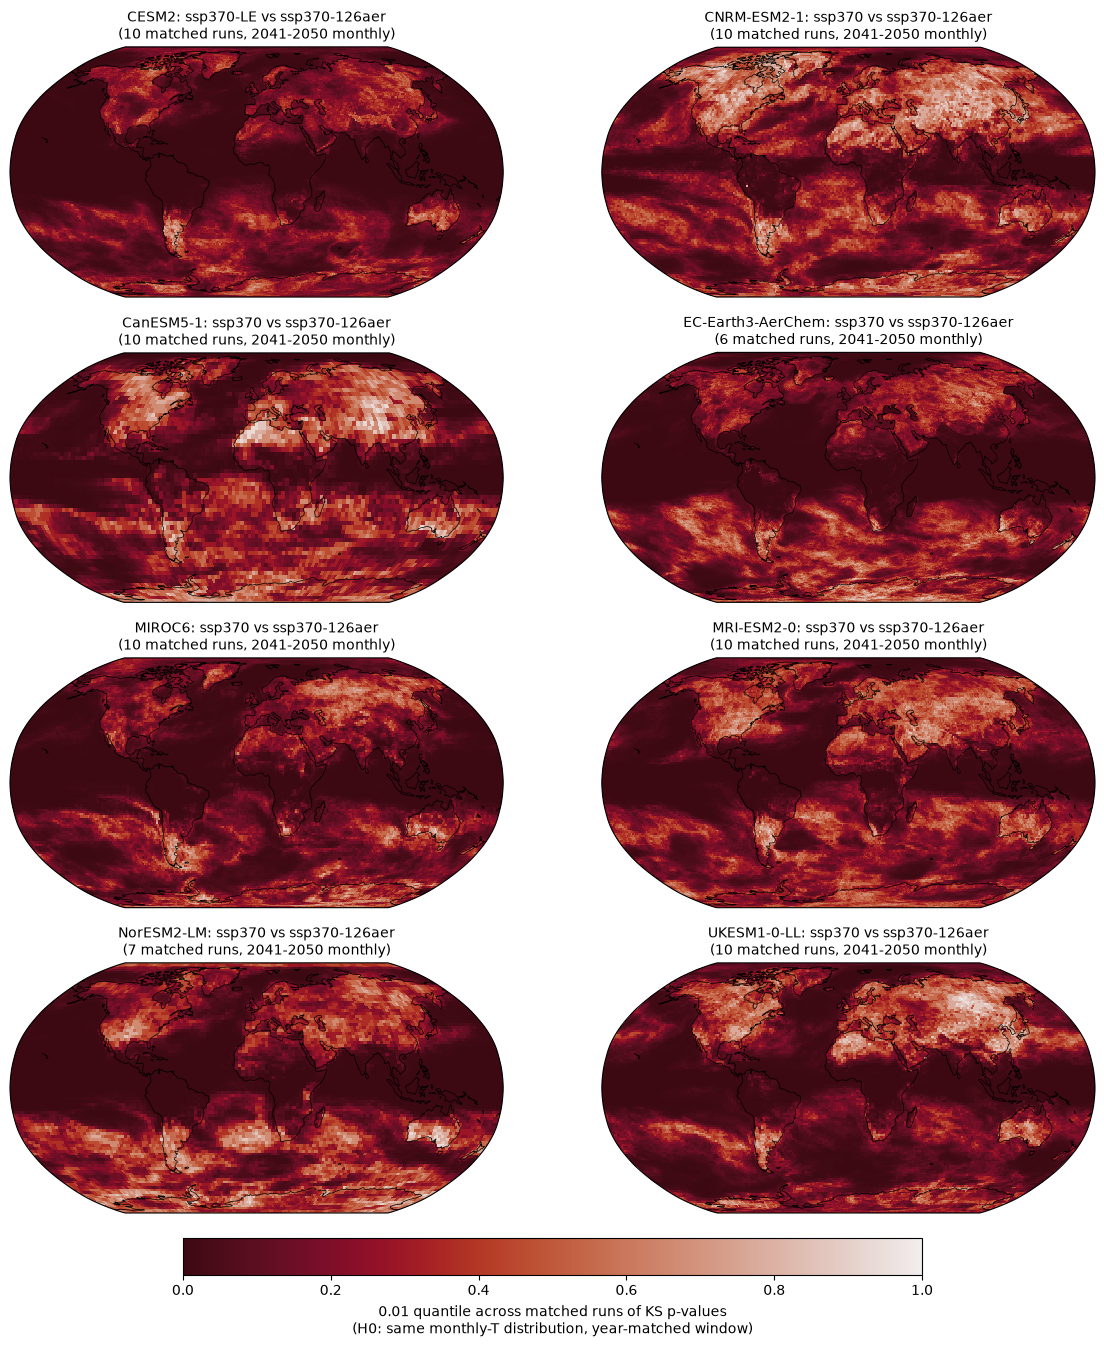

In [7]:
fig, axs = plt.subplots(4, 2, figsize=(14, 16),
                        subplot_kw={'projection': ccrs.Robinson()})
for ax, mod in zip(axs.flat, MODELS):
    v = q01[mod]
    im = ax.pcolormesh(v.lon, v.lat, v, transform=ccrs.PlateCarree(),
                       cmap=cmocean.cm.amp_r, vmin=0, vmax=1)
    ax.coastlines(lw=0.5)
    ax.set_title(f'{mod}: {ANCHOR[mod]} vs {OTHER}\n'
                 f'({results[mod].sizes["run"]} matched runs, {YEARS[0]}-{YEARS[1]} monthly)',
                 fontsize=10)
fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.03, pad=0.02,
             label='0.01 quantile across matched runs of KS p-values\n'
                   '(H0: same monthly-T distribution, year-matched window)')
out_dir = dir_list['aux'] + '../figures/'
fig.savefig(out_dir + 'ks_pvalue_maps_ramip_multi.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'ks_pvalue_maps_ramip_multi.png')

In [8]:
#Take a couple of sample pixels, locations with pvalues (high, mid, low), show the histograms and cdfs
#comparison method write up (autocorrelation)
#turn result into box plot figures (fig 2 from paper)

## Sample pixels: what the p-values look like in the raw data

Three land pixels (Antarctica excluded) from EC-Earth3-AerChem run 0, picked nearest to target p = 0.001 / 0.5 / 0.95 on its p-map. Top row: histograms of the 120 monthly tas values per experiment (bimodal shape = seasonal cycle, same both sides, cancels in KS). Bottom row: ECDFs with the KS statistic D marked as the max vertical gap. Low-p pixel (Mato Grosso, Brazil) shows the classic aerosol-cleanup warm shift (~+1 °C); high-p pixel's ECDFs are indistinguishable.

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_sample_pixels_ramip_multi.png
low  p=0.0008627  lat=-17.89  lon=-54.84
mid  p=0.4505  lat=-55.09  lon=-69.61
high p=0.9362  lat=-48.07  lon=-66.80


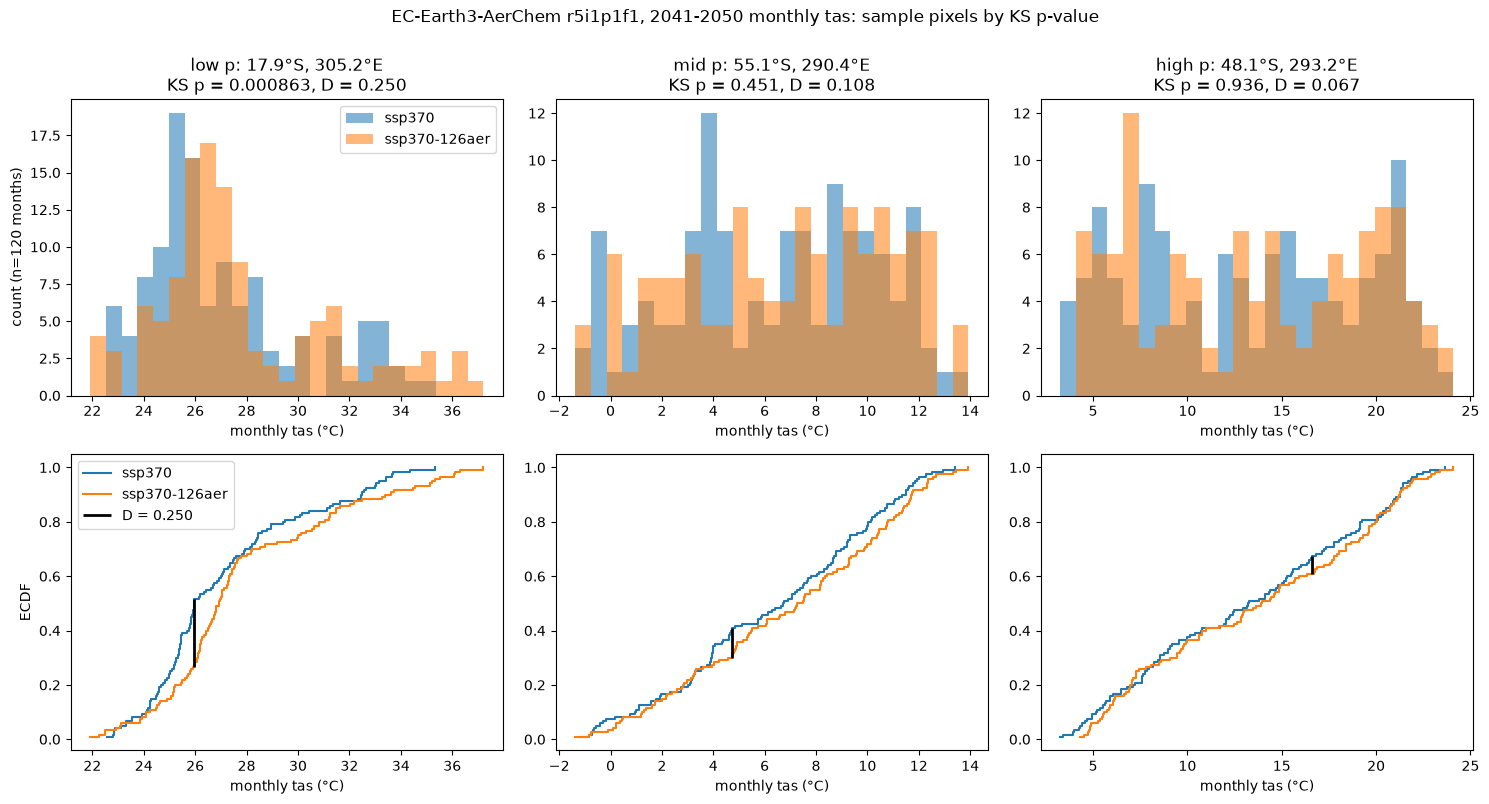

In [9]:
# sample pixels by KS p (low/mid/high): histograms + ECDFs
MOD_S = 'EC-Earth3-AerChem'   # strongest aerosol signal of the 8
pv_s  = results[MOD_S]
run_s = str(pv_s.run.values[0])
p0    = pv_s.isel(run=0)

lm_s   = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(p0.lon, p0.lat)
land_s = (lm_s == 0).values & (p0.lat > -60).values[:, None]   # land, no Antarctica

picks = {}
for name, t in {'low': 0.001, 'mid': 0.5, 'high': 0.95}.items():
    masked = np.where(land_s & np.isfinite(p0.values), np.abs(p0.values - t), np.inf)
    picks[name] = np.unravel_index(np.argmin(masked), p0.shape)

def pixel_vals(exp, iy, ix):
    ds = xr.open_zarr(member_files(MOD_S, exp)[run_s], consolidated=False)
    da = ds['tas'].sel(time=(ds.time.dt.year >= YEARS[0]) & (ds.time.dt.year <= YEARS[1]))
    return da.isel(lat=iy, lon=ix).load().values - 273.15

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
for col, (name, (iy, ix)) in enumerate(picks.items()):
    a = pixel_vals(ANCHOR[MOD_S], iy, ix)
    b = pixel_vals(OTHER, iy, ix)
    ks = sstats.kstest(a, b, method='asymp')
    lat_v, lon_v = float(p0.lat[iy]), float(p0.lon[ix])
    loc = f'{abs(lat_v):.1f}°{"N" if lat_v >= 0 else "S"}, {lon_v % 360:.1f}°E'

    ax = axs[0, col]
    bins = np.histogram_bin_edges(np.concatenate([a, b]), bins=25)
    ax.hist(a, bins=bins, alpha=0.55, label=ANCHOR[MOD_S], color='tab:blue')
    ax.hist(b, bins=bins, alpha=0.55, label=OTHER, color='tab:orange')
    ax.set_title(f'{name} p: {loc}\nKS p = {ks.pvalue:.3g}, D = {ks.statistic:.3f}')
    ax.set_xlabel('monthly tas (°C)')
    if col == 0:
        ax.set_ylabel(f'count (n={len(a)} months)')
        ax.legend()

    ax = axs[1, col]
    for v, lab, c in [(a, ANCHOR[MOD_S], 'tab:blue'), (b, OTHER, 'tab:orange')]:
        xs = np.sort(v)
        ax.step(xs, np.arange(1, len(xs) + 1) / len(xs), where='post', label=lab, color=c)
    # mark the KS D: max vertical gap between the two ECDFs
    grid = np.sort(np.concatenate([a, b]))
    Fa = np.searchsorted(np.sort(a), grid, side='right') / len(a)
    Fb = np.searchsorted(np.sort(b), grid, side='right') / len(b)
    k = np.argmax(np.abs(Fa - Fb))
    ax.vlines(grid[k], min(Fa[k], Fb[k]), max(Fa[k], Fb[k]),
              color='k', lw=2, label=f'D = {ks.statistic:.3f}')
    ax.set_xlabel('monthly tas (°C)')
    if col == 0:
        ax.set_ylabel('ECDF')
        ax.legend()

fig.suptitle(f'{MOD_S} {run_s}, {YEARS[0]}-{YEARS[1]} monthly tas: sample pixels by KS p-value', y=1.0)
fig.tight_layout()
fig.savefig(out_dir + 'ks_sample_pixels_ramip_multi.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'ks_sample_pixels_ramip_multi.png')
for name, (iy, ix) in picks.items():
    print(f'{name:4s} p={p0.values[iy, ix]:.4g}  lat={float(p0.lat[iy]):.2f}  lon={float(p0.lon[ix]):.2f}')